# MVP v0.2.5.6: Cross-Policy Guidance — Prove Guidance Effectiveness

**Date:** 2026-03-13  
**Builds on:** v0.2.5.5 (corrected guidance settings work, but target ≈ behavior made it inconclusive)

## Goal

Prove that positive guidance carries target policy information by evaluating
**6 different target policies** using a **single fixed diffuser** (trained on 54% SR behavior data).

**Hypothesis:**
- Unguided OPE should be flat (~0.60) across all targets (diffuser is fixed)
- Guided OPE should correlate with oracle SR (guidance steers toward target)

**Success criterion:** Spearman ρ > 0.8 between guided OPE and oracle SR.

In [1]:
%matplotlib inline
import sys, os, importlib
import numpy as np
import torch
import torch.nn as nn
import h5py, json, math, time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_BASE = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models"
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
ORACLE_JSON = PROJECT_ROOT / "results/2026-03-12/oracle_eval_all_checkpoints.json"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# Dims
STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = 26
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

# Diffuser config (must match v0.2.5.2 training)
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0

# Generation config
NUM_SYNTHETIC = 50
T_GEN = 60
GAMMA = 1.0

# Guidance config (best from v0.2.5.5)
SCORE_TIMESTEP = 5
ACTION_SCALE = 0.001

# Target policies to evaluate (chosen for SR spread)
TARGET_POLICIES = [
    {"name": "10demos_epoch10",  "dir": "lift_diffusion_10demos/20260311115828",  "ckpt": "models/model_epoch_10.pth"},
    {"name": "100demos_epoch20", "dir": "lift_diffusion_100demos/20260311135551", "ckpt": "models/model_epoch_20.pth"},
    {"name": "test_checkpoint",  "dir": "test/20260309132349",                   "ckpt": "last.pth"},
    {"name": "10demos_epoch30",  "dir": "lift_diffusion_10demos/20260311115828",  "ckpt": "models/model_epoch_30.pth"},
    {"name": "50demos_epoch30",  "dir": "lift_diffusion_50demos/20260311134204",  "ckpt": "models/model_epoch_30.pth"},
    {"name": "200demos_epoch40", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_40.pth"},
]

print(f"score_timestep={SCORE_TIMESTEP}, action_scale={ACTION_SCALE}")
print(f"{NUM_SYNTHETIC} trajs, T_GEN={T_GEN}")
print(f"{len(TARGET_POLICIES)} target policies to evaluate")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
score_timestep=5, action_scale=0.001
50 trajs, T_GEN=60
6 target policies to evaluate


In [2]:
# ── Load oracle results ──
with open(ORACLE_JSON, "r") as f:
    oracle_all = json.load(f)

# Map policy names to oracle SR
oracle_sr_map = {}
for pol in TARGET_POLICIES:
    name = pol["name"]
    if name == "test_checkpoint":
        # Test checkpoint oracle from its own file
        with open(CKPT_BASE / "test/20260309132349/oracle_50.json", "r") as f:
            test_oracle = json.load(f)
        oracle_sr_map[name] = float(test_oracle["mean_return"])
    else:
        oracle_sr_map[name] = float(oracle_all[name]["mean_return"])

print("Oracle SR values:")
for name, sr in oracle_sr_map.items():
    print(f"  {name:<22} {sr*100:.0f}%")

Oracle SR values:
  10demos_epoch10        8%
  100demos_epoch20       42%
  test_checkpoint        54%
  10demos_epoch30        62%
  50demos_epoch30        82%
  200demos_epoch40       90%


In [3]:
# ── Load target rollouts (for initial states) and expert demos (for normalization) ──
target_data = []
all_states_list, all_actions_list = [], []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    actions = actions.astype(np.float32)
    target_data.append({"states": states, "actions": actions})
    all_states_list.append(states)
    all_actions_list.append(actions)
print(f"Loaded {len(target_data)} target rollouts")

# Expert demos
with h5py.File(DEMO_HDF5, "r") as f:
    for dk in sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1])):
        demo = f[f"data/{dk}"]
        states = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS], axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        all_states_list.append(states)
        all_actions_list.append(actions)
print(f"Loaded 200 expert demos")

# Normalization (same as v0.2.5.2 training)
all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

# Initial states for generation (from behavior/test checkpoint rollouts)
initial_states_t = torch.tensor(
    np.array([ep["states"][0] for ep in target_data[:NUM_SYNTHETIC]]),
    dtype=torch.float32, device=device
)
print(f"Initial states: {initial_states_t.shape}")

Loaded 50 target rollouts


Loaded 200 expert demos
Initial states: torch.Size([50, 19])


In [4]:
# ── Load pre-trained diffuser ──
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)
ema = EMA(diffusion_model)
ema.ema_model.load_state_dict(
    torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
)
print(f"Loaded EMA diffuser from {DIFFUSION_SAVE_DIR}")

[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]


[(26, 32), (32, 128), (128, 256)]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Loaded EMA diffuser from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse


In [5]:
def generate_trajectories(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen, device,
    target_scorer=None,
    action_scale=0.0, normalize_grad=True,
):
    guided = (target_scorer is not None and action_scale > 0)
    B = initial_states.shape[0]
    td = state_dim + action_dim
    n_ts = diffusion_model.n_timesteps

    pad = torch.cat([initial_states, torch.zeros(B, action_dim, device=device)], 1)
    cond_init = normalize_fn(pad)[:, :state_dim]
    all_traj = torch.zeros(B, t_gen, td, device=device)
    conditions = {0: cond_init}
    total = 0

    while total < t_gen:
        x = torch.randn(B, chunk_size, td, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_d in reversed(range(n_ts)):
            t_t = torch.full((B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = diffusion_model.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)

            if guided:
                mm = unnormalize_fn(mm)
                sc = mm[:, :, :state_dim]
                ac = mm[:, :, state_dim:]
                tg = target_scorer.grad_log_prob_chunk(sc, ac)
                if normalize_grad:
                    tg = tg / (tg.norm(dim=-1, keepdim=True) + 1e-6)
                guide = torch.zeros_like(mm)
                guide[:, :, state_dim:] = tg
                mm = mm + action_scale * guide
                mm = normalize_fn(mm)
                mm = apply_conditioning(mm, conditions, state_dim)
                mm = unnormalize_fn(mm)
                mm = normalize_fn(mm)

            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, conditions, state_dim)

        chunk_u = unnormalize_fn(x)
        n_store = min(chunk_size - 1, t_gen - total)
        all_traj[:, total:total+n_store] = chunk_u[:, :n_store]
        total += n_store
        if total >= t_gen:
            break
        conditions = {0: x[:, -1, :state_dim]}

    return all_traj.detach().cpu().numpy()

print("Generator ready.")

Generator ready.


In [6]:
# ── Generate unguided trajectories (once — same for all targets) ──
print("Generating unguided trajectories...")
np.random.seed(42)
torch.manual_seed(42)

t0 = time.time()
unguided_trajs = generate_trajectories(
    diffusion_model=ema.ema_model,
    initial_states=initial_states_t,
    normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
    state_dim=STATE_DIM, action_dim=ACTION_DIM,
    chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
)
unguided_time = time.time() - t0

unguided_states = unguided_trajs[:, :, :STATE_DIM]
unguided_sr = np.mean([np.any(unguided_states[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD)
                       for j in range(NUM_SYNTHETIC)])
unguided_ope = float(unguided_sr)  # binary reward, gamma=1
print(f"Unguided: SR={unguided_sr*100:.0f}%, OPE={unguided_ope:.3f}, {unguided_time:.0f}s")

Generating unguided trajectories...


Unguided: SR=60%, OPE=0.600, 31s


In [7]:
# ── Loop over target policies: generate guided trajectories ──
results = {}
t0_all = time.time()

for i, pol in enumerate(TARGET_POLICIES):
    name = pol["name"]
    oracle_sr = oracle_sr_map[name]
    run_dir = CKPT_BASE / pol["dir"]
    ckpt_file = pol["ckpt"]
    
    print(f"\n[{i+1}/{len(TARGET_POLICIES)}] {name} (oracle={oracle_sr*100:.0f}%)")
    
    # Load target policy
    print(f"  Loading checkpoint...", end=" ", flush=True)
    t0 = time.time()
    ckpt = load_checkpoint(run_dir, ckpt_path=Path(ckpt_file))
    target_algo = build_algo_from_checkpoint(ckpt, device=str(device))
    target_scorer = RobomimicDiffusionScorer(
        target_algo, device=str(device), score_timestep=SCORE_TIMESTEP, obs_keys=OBS_KEYS
    )
    load_time = time.time() - t0
    print(f"{load_time:.0f}s")
    
    # Generate guided trajectories
    print(f"  Generating guided trajectories...", end=" ", flush=True)
    np.random.seed(42)
    torch.manual_seed(42)
    t0 = time.time()
    guided_trajs = generate_trajectories(
        diffusion_model=ema.ema_model,
        initial_states=initial_states_t,
        normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM, action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
        target_scorer=target_scorer,
        action_scale=ACTION_SCALE, normalize_grad=True,
    )
    gen_time = time.time() - t0
    
    guided_states = guided_trajs[:, :, :STATE_DIM]
    guided_sr = np.mean([np.any(guided_states[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD)
                         for j in range(NUM_SYNTHETIC)])
    guided_ope = float(guided_sr)
    
    results[name] = {
        "oracle_sr": oracle_sr,
        "guided_sr": guided_sr,
        "guided_ope": guided_ope,
        "guided_states": guided_states,
        "gen_time": gen_time,
    }
    
    print(f"{gen_time:.0f}s — Guided SR={guided_sr*100:.0f}% (oracle={oracle_sr*100:.0f}%)")
    
    # Free GPU memory
    del target_algo, target_scorer, ckpt
    torch.cuda.empty_cache()

total_time = time.time() - t0_all
print(f"\nTotal sweep time: {total_time:.0f}s ({total_time/60:.1f} min)")


[1/6] 10demos_epoch10 (oracle=8%)
  Loading checkpoint... 


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_pos', 'object', 'robot0_eef_quat']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[17:32:08] INFO     build_algo_from_checkpoint took 0.40 seconds to execute                           ]8;id=996293;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=84124;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

43s
  Generating guided trajectories... 

...


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_pos', 'object', 'robot0_eef_quat']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[17:41:06] INFO     build_algo_from_checkpoint took 0.39 seconds to execute                           ]8;id=66658;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=54959;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

40s
  Generating guided trajectories... 

69s — Guided SR=58% (oracle=90%)

Total sweep time: 651s (10.8 min)


In [8]:
# ── Summary table ──
print(f"{'='*85}")
print(f"v0.2.5.6 CROSS-POLICY GUIDANCE TEST")
print(f"Diffuser: trained on test checkpoint (54% SR behavior)")
print(f"Guidance: score_timestep={SCORE_TIMESTEP}, action_scale={ACTION_SCALE}, pos-only")
print(f"{'='*85}")
print(f"\n{'Policy':<22} {'Oracle':>7} {'Unguided':>9} {'Guided':>8} {'Δ(G-U)':>8} {'G err':>7} {'U err':>7}")
print("-" * 75)

oracle_srs = []
guided_opes = []
unguided_opes = []

for name in [p["name"] for p in TARGET_POLICIES]:
    r = results[name]
    osr = r["oracle_sr"]
    gsr = r["guided_sr"]
    delta = gsr - unguided_ope
    g_err = abs(gsr - osr) / (osr + 1e-8) * 100
    u_err = abs(unguided_ope - osr) / (osr + 1e-8) * 100
    
    oracle_srs.append(osr)
    guided_opes.append(gsr)
    unguided_opes.append(unguided_ope)
    
    print(f"{name:<22} {osr*100:>6.0f}% {unguided_ope*100:>8.0f}% {gsr*100:>7.0f}% "
          f"{delta*100:>+7.0f}% {g_err:>6.1f}% {u_err:>6.1f}%")

# Rank correlations
spearman_guided, p_guided = stats.spearmanr(oracle_srs, guided_opes)
spearman_unguided, p_unguided = stats.spearmanr(oracle_srs, unguided_opes)

print(f"\n{'='*85}")
print(f"Spearman ρ (guided  vs oracle): {spearman_guided:+.4f}  (p={p_guided:.4f})")
print(f"Spearman ρ (unguided vs oracle): {spearman_unguided:+.4f}  (p={p_unguided:.4f})")
print(f"\nUnguided OPE (flat baseline): {unguided_ope:.3f}")
print(f"Guided OPE range: [{min(guided_opes):.3f}, {max(guided_opes):.3f}]")

if spearman_guided > 0.8:
    print(f"\n✓ SUCCESS: Guidance carries target policy information (ρ={spearman_guided:.2f} > 0.8)")
elif spearman_guided > 0.5:
    print(f"\n~ PARTIAL: Guidance shows some correlation (ρ={spearman_guided:.2f})")
else:
    print(f"\n✗ FAIL: Guidance does not meaningfully differentiate policies (ρ={spearman_guided:.2f})")

v0.2.5.6 CROSS-POLICY GUIDANCE TEST
Diffuser: trained on test checkpoint (54% SR behavior)
Guidance: score_timestep=5, action_scale=0.001, pos-only

Policy                  Oracle  Unguided   Guided   Δ(G-U)   G err   U err
---------------------------------------------------------------------------
10demos_epoch10             8%       60%      58%      -2%  625.0%  650.0%
100demos_epoch20           42%       60%      62%      +2%   47.6%   42.9%
test_checkpoint            54%       60%      62%      +2%   14.8%   11.1%
10demos_epoch30            62%       60%      58%      -2%    6.5%    3.2%
50demos_epoch30            82%       60%      62%      +2%   24.4%   26.8%
200demos_epoch40           90%       60%      58%      -2%   35.6%   33.3%

Spearman ρ (guided  vs oracle): -0.0976  (p=0.8541)
Spearman ρ (unguided vs oracle): +nan  (p=nan)

Unguided OPE (flat baseline): 0.600
Guided OPE range: [0.580, 0.620]

✗ FAIL: Guidance does not meaningfully differentiate policies (ρ=-0.10)


/tmp/SLURM_7381032/ipykernel_673921/914008300.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_unguided, p_unguided = stats.spearmanr(oracle_srs, unguided_opes)


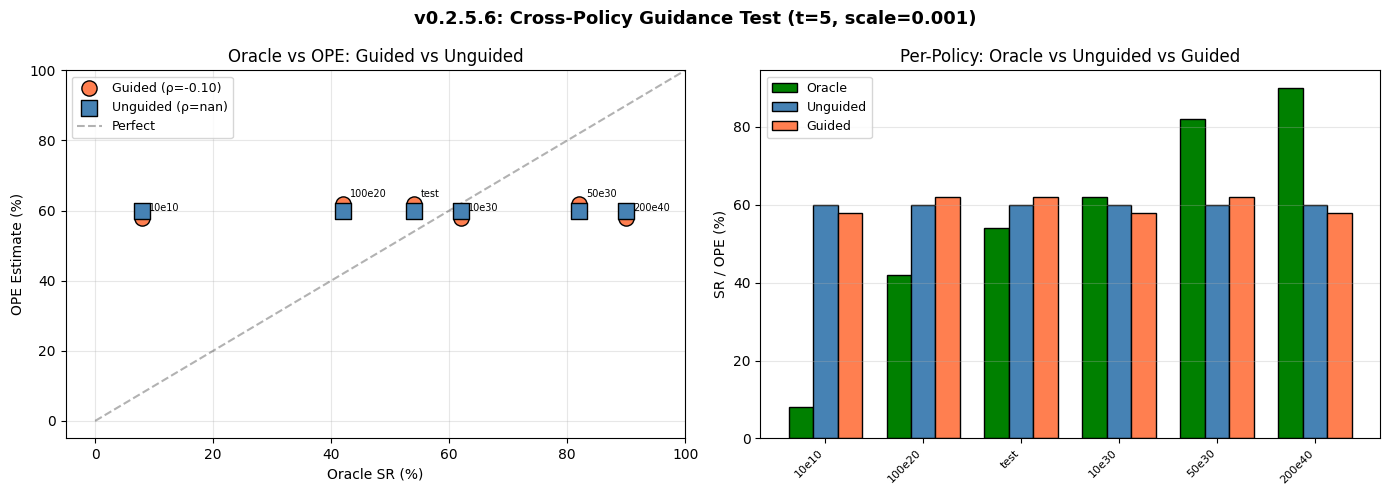

In [9]:
# ── Figure 1: Oracle vs OPE scatter plot (the key result) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Scatter
ax = axes[0]
ax.scatter(np.array(oracle_srs)*100, np.array(guided_opes)*100, 
           s=120, c="coral", edgecolor="black", zorder=5, label=f"Guided (ρ={spearman_guided:.2f})")
ax.scatter(np.array(oracle_srs)*100, np.array(unguided_opes)*100,
           s=120, c="steelblue", edgecolor="black", marker="s", zorder=5, label=f"Unguided (ρ={spearman_unguided:.2f})")
# Perfect line
ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label="Perfect")
# Label points
for j, name in enumerate([p["name"] for p in TARGET_POLICIES]):
    ax.annotate(name.replace("demos_epoch", "e").replace("test_checkpoint", "test"),
                (oracle_srs[j]*100, guided_opes[j]*100),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
ax.set_xlabel("Oracle SR (%)")
ax.set_ylabel("OPE Estimate (%)")
ax.set_title("Oracle vs OPE: Guided vs Unguided")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([-5, 100])
ax.set_ylim([-5, 100])

# Panel 2: Bar chart comparison
ax = axes[1]
x = np.arange(len(TARGET_POLICIES))
w = 0.25
names = [p["name"].replace("demos_epoch", "e").replace("test_checkpoint", "test") 
         for p in TARGET_POLICIES]
ax.bar(x - w, np.array(oracle_srs)*100, w, color="green", edgecolor="black", label="Oracle")
ax.bar(x, np.array(unguided_opes)*100, w, color="steelblue", edgecolor="black", label="Unguided")
ax.bar(x + w, np.array(guided_opes)*100, w, color="coral", edgecolor="black", label="Guided")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("SR / OPE (%)")
ax.set_title("Per-Policy: Oracle vs Unguided vs Guided")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"v0.2.5.6: Cross-Policy Guidance Test (t={SCORE_TIMESTEP}, scale={ACTION_SCALE})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

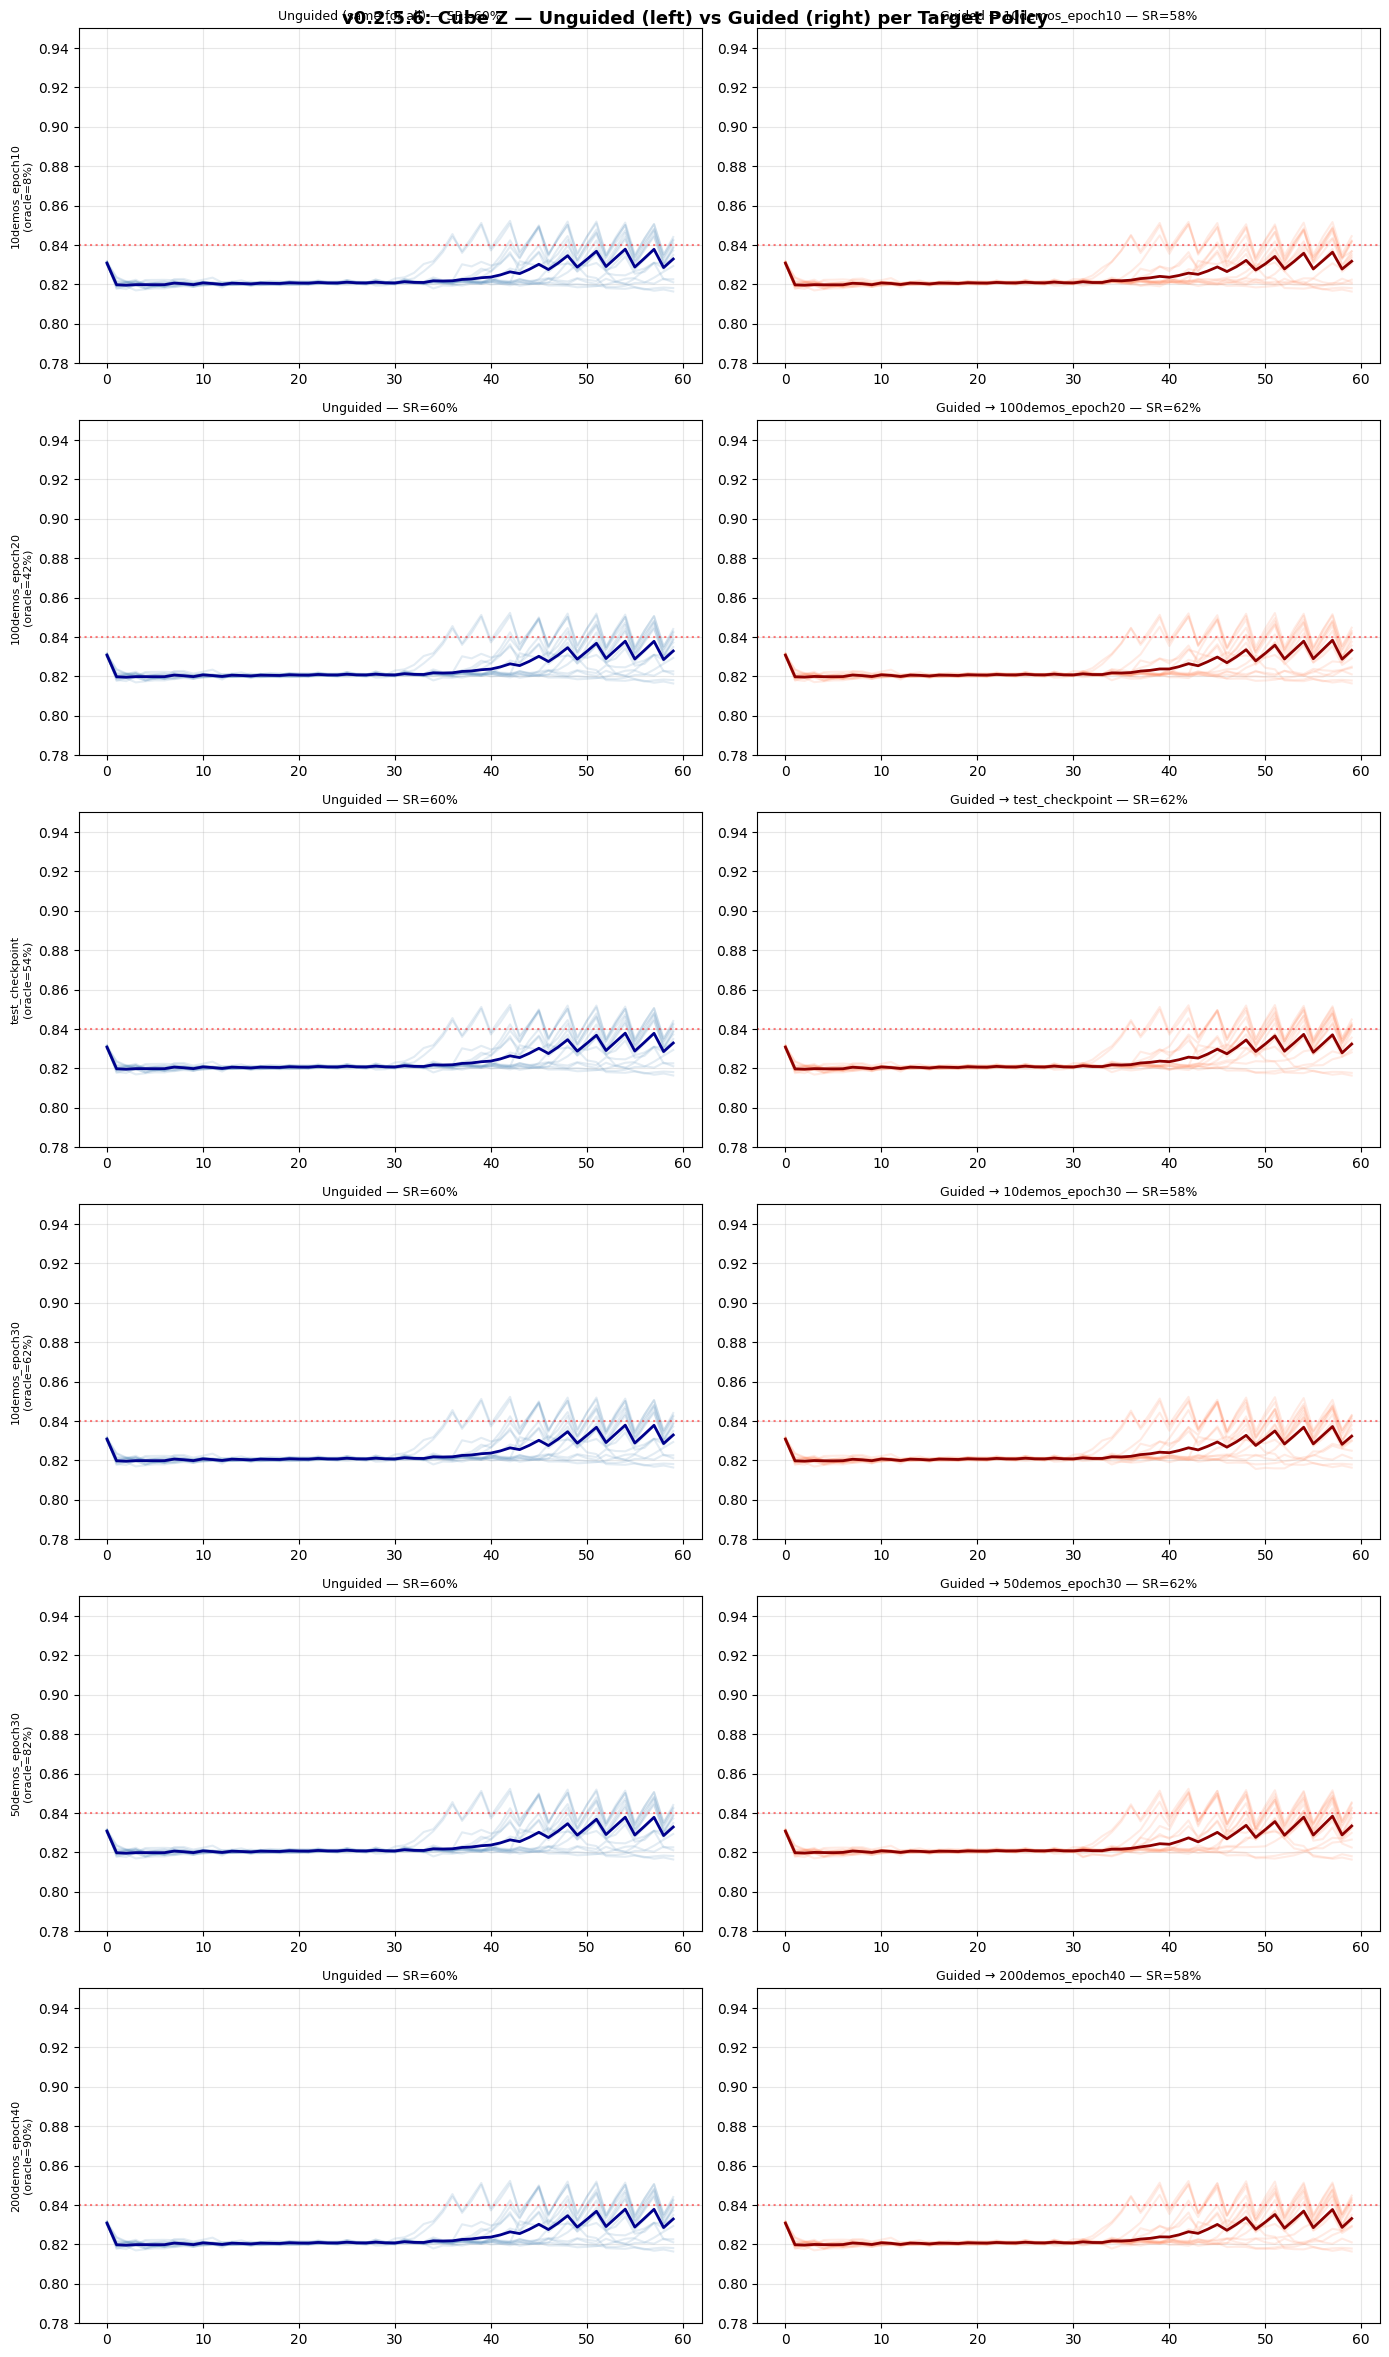

In [10]:
# ── Figure 2: Cube z trajectory grid (one row per policy) ──
n_policies = len(TARGET_POLICIES)
fig, axes = plt.subplots(n_policies, 2, figsize=(14, 4*n_policies))

for row, pol in enumerate(TARGET_POLICIES):
    name = pol["name"]
    r = results[name]
    osr = r["oracle_sr"]
    gs = r["guided_states"]
    
    # Left: unguided
    ax = axes[row, 0]
    for j in range(min(15, NUM_SYNTHETIC)):
        ax.plot(unguided_states[j, :, CUBE_Z_INDEX], color="steelblue", alpha=0.15)
    ax.plot(unguided_states[:, :, CUBE_Z_INDEX].mean(0), color="darkblue", lw=2)
    ax.axhline(y=LIFT_THRESHOLD, color="red", ls=":", alpha=0.5)
    ax.set_ylim([0.78, 0.95])
    ax.set_title(f"Unguided — SR={unguided_sr*100:.0f}%", fontsize=9)
    ax.set_ylabel(f"{name}\n(oracle={osr*100:.0f}%)", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Right: guided toward this target
    ax = axes[row, 1]
    for j in range(min(15, NUM_SYNTHETIC)):
        ax.plot(gs[j, :, CUBE_Z_INDEX], color="coral", alpha=0.15)
    ax.plot(gs[:, :, CUBE_Z_INDEX].mean(0), color="darkred", lw=2)
    ax.axhline(y=LIFT_THRESHOLD, color="red", ls=":", alpha=0.5)
    ax.set_ylim([0.78, 0.95])
    ax.set_title(f"Guided → {name} — SR={r['guided_sr']*100:.0f}%", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_title(f"Unguided (same for all) — SR={unguided_sr*100:.0f}%", fontsize=9)
plt.suptitle("v0.2.5.6: Cube Z — Unguided (left) vs Guided (right) per Target Policy",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

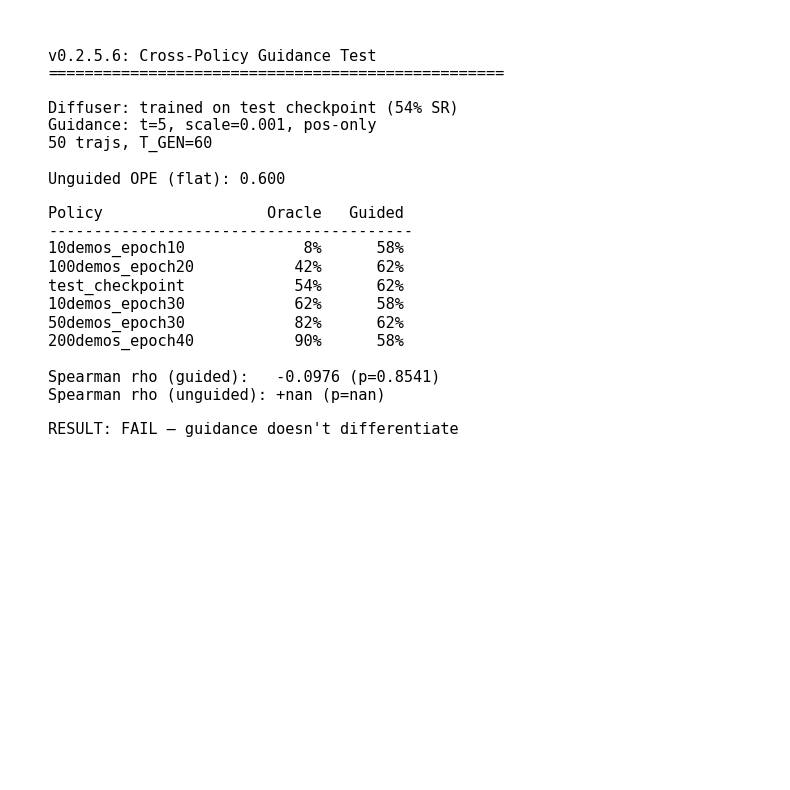

In [11]:
# ── Figure 3: Summary ──
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.axis("off")

summary_lines = [
    "v0.2.5.6: Cross-Policy Guidance Test",
    "=" * 50,
    "",
    f"Diffuser: trained on test checkpoint (54% SR)",
    f"Guidance: t={SCORE_TIMESTEP}, scale={ACTION_SCALE}, pos-only",
    f"{NUM_SYNTHETIC} trajs, T_GEN={T_GEN}",
    "",
    f"Unguided OPE (flat): {unguided_ope:.3f}",
    "",
]

summary_lines.append(f"{'Policy':<22} {'Oracle':>7} {'Guided':>8}")
summary_lines.append("-" * 40)
for name in [p["name"] for p in TARGET_POLICIES]:
    r = results[name]
    summary_lines.append(f"{name:<22} {r['oracle_sr']*100:>6.0f}% {r['guided_sr']*100:>7.0f}%")

summary_lines += [
    "",
    f"Spearman rho (guided):   {spearman_guided:+.4f} (p={p_guided:.4f})",
    f"Spearman rho (unguided): {spearman_unguided:+.4f} (p={p_unguided:.4f})",
    "",
]

if spearman_guided > 0.8:
    summary_lines.append("RESULT: SUCCESS — guidance differentiates policies")
elif spearman_guided > 0.5:
    summary_lines.append("RESULT: PARTIAL — some correlation")
else:
    summary_lines.append("RESULT: FAIL — guidance doesn't differentiate")

ax.text(0.05, 0.95, "\n".join(summary_lines), transform=ax.transAxes,
        fontsize=11, verticalalignment="top", fontfamily="monospace")
plt.tight_layout()
plt.show()